# Time series generation through Kalman filtering and state-space modeling

In signal processing, any stationary signal can be regarded as the output of a linear time-invariant (LTI) system excited by white noise. The **Kalman filter** provides a recursive framework for estimating the latent state of such a dynamical system from noisy observations, and for simulating new trajectories by driving the learned state equation with fresh white-noise excitations.

Compared with the Wiener-filter-based generator (which implements the same white-noise-to-signal mapping through linear filtering), the Kalman-filter simulator exposes the mapping in **explicit state-space form**. This formulation is the standard tool in modern signal processing and complex-system modeling for recursive estimation, prediction, and simulation of linear Gaussian dynamical systems.

This notebook introduces the method in the following order:

1. Elaboration of the basic mathematical principles.
2. Step-by-step construction of the state-space model from input data.
3. Generation of new time series by white-noise excitation.
4. Visualization and statistical comparison with the input sequence.
5. Usage of the encapsulated `KalmanFilterSimulator` in S2Generator.

## State-space AR model and the Kalman filter

Suppose the input stationary sequence $y_t$ can be approximated by an $\mathrm{AR}(p)$ process driven by white noise $w_t \sim \mathcal{N}(0, \sigma^2)$:
$$
y_t + \varphi_1 y_{t-1} + \varphi_2 y_{t-2} + \cdots + \varphi_p y_{t-p} = w_t. \quad (1)
$$

Define the companion state vector $x_t = [y_t, y_{t-1}, \ldots, y_{t-p+1}]^\top$. Equation (1) can be rewritten in state-space form as:
$$
x_t = F x_{t-1} + G w_t, \quad y_t = H x_t, \quad (2)
$$
where
$$
F = \begin{bmatrix}
-\varphi_1 & -\varphi_2 & \cdots & -\varphi_p \\
1 & 0 & \cdots & 0 \\
0 & 1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & 0
\end{bmatrix}, \quad
G = \begin{bmatrix} 1 \\ 0 \\ \vdots \\ 0 \end{bmatrix}, \quad
H = \begin{bmatrix} 1 & 0 & \cdots & 0 \end{bmatrix}.
$$

The process-noise covariance is $Q = \sigma^2 G G^\top$, and a tiny observation-noise variance $R$ is used during filtering for numerical stability.

### Parameter estimation via Yule–Walker equations

Given the autocorrelation function $r(k)$ of the input sequence, we construct the Toeplitz matrix $R_{yy}$ and solve the Yule–Walker equations:
$$
R_{yy} \begin{bmatrix} 1 \\ \varphi_1 \\ \vdots \\ \varphi_p \end{bmatrix}
= \begin{bmatrix} \sigma^2 \\ 0 \\ \vdots \\ 0 \end{bmatrix}. \quad (3)
$$

This step is identical to the coefficient estimation used in the Wiener-filter simulator. The Kalman-filter formulation then uses the estimated $(F, G, H, Q, R)$ for recursive one-step prediction and innovation analysis.

### Kalman filter recursion

During fitting, the observed sequence $y_t$ is processed recursively. Let $x_{t|t-1}$ and $P_{t|t-1}$ denote the predicted state and covariance. The filter performs:
$$
\hat{y}_{t|t-1} = H x_{t|t-1}, \quad \nu_t = y_t - \hat{y}_{t|t-1}, \quad (4)
$$
$$
K_t = P_{t|t-1} H^\top (H P_{t|t-1} H^\top + R)^{-1}, \quad x_{t|t} = x_{t|t-1} + K_t \nu_t. \quad (5)
$$

The innovation $\nu_t$ should be approximately white if the AR order is adequate.

### Data generation by white-noise excitation

To synthesize a new sequence, we discard observations and propagate the state equation forward:
$$
x_t = F x_{t-1} + G w_t, \quad w_t \sim \mathcal{N}(0, \sigma^2). \quad (6)
$$

The output sample path $y_t = (x_t)_1$ preserves the second-order statistics (autocorrelation and power spectral density) learned from the input data. This is the same white-noise-to-signal generation philosophy as the Wiener and ARIMA simulators in S2Generator.

Below we import the required libraries and load a real spectrum sequence for demonstration.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from scipy.linalg import toeplitz
from statsmodels.tsa.stattools import acf

from s2generator.simulator import KalmanFilterSimulator
from s2generator.utils import (
    yule_walker,
    plot_simulator_statistics,
    plot_univariate_time_series,
)

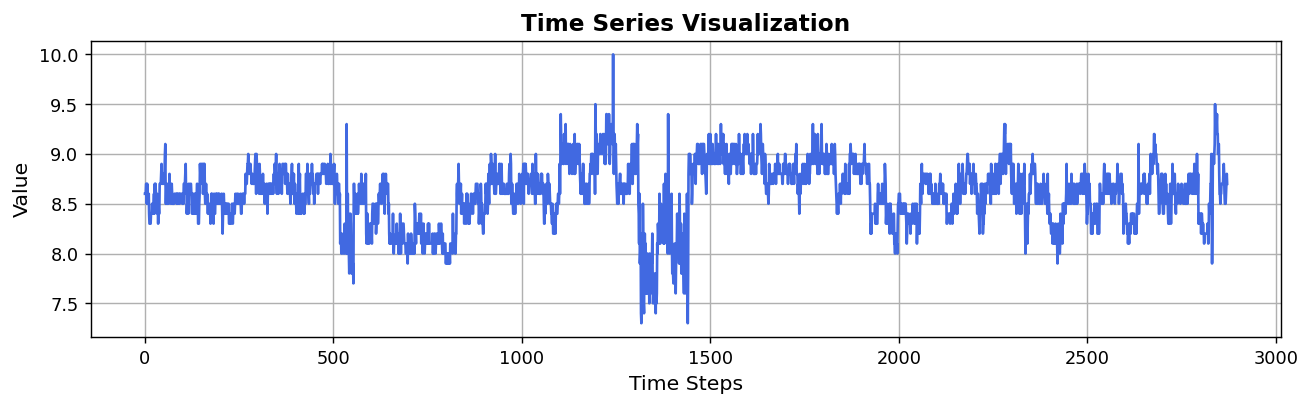

In [2]:
time_series = np.load("..\\docs\\source\\_static\\spectrum.npy")
fig = plot_univariate_time_series(time_series, dpi=128)

## Step 1: Estimate AR parameters from autocorrelations

We first normalize the input sequence, compute its autocorrelation function, build the Toeplitz matrix, and solve the Yule–Walker equations.

In [3]:
# Hyperparameters
state_order = 8  # length of [1, phi_1, ..., phi_p], same meaning as filter_order in WienerFilterSimulator

# Reversible normalization
mean, std = np.mean(time_series), np.std(time_series)
normalized_series = (time_series - mean) / std

# Autocorrelation and Toeplitz matrix
acf_vals = acf(normalized_series, nlags=state_order * 2, fft=True)
R = toeplitz(acf_vals[:state_order])

coeffs, sigma_sq = yule_walker(A=R)
phi = coeffs[1:]
p = len(phi)

print("AR coefficient vector:", coeffs)
print("Process noise variance sigma^2:", sigma_sq)
print("Latent state dimension:", p)

AR coefficient vector: [ 1.         -0.50695985 -0.12302034 -0.14677549 -0.04707042 -0.05037847
 -0.03822214 -0.02872338]
Process noise variance sigma^2: 0.22269476611451222
Latent state dimension: 7


## Step 2: Construct the state-space matrices

From the estimated AR coefficients we build the companion matrices $F$, $G$, $H$, and the process-noise covariance $Q$.

In [4]:
F = np.zeros((p, p))
F[0, :] = -phi
if p > 1:
    F[1:, :-1] = np.eye(p - 1)

G = np.zeros((p, 1))
G[0, 0] = 1.0

H = np.zeros((1, p))
H[0, 0] = 1.0

Q = sigma_sq * (G @ G.T)
R = 1e-8

print("F shape:", F.shape)
print("F =\n", F)

F shape: (7, 7)
F =
 [[0.50695985 0.12302034 0.14677549 0.04707042 0.05037847 0.03822214
  0.02872338]
 [1.         0.         0.         0.         0.         0.
  0.        ]
 [0.         1.         0.         0.         0.         0.
  0.        ]
 [0.         0.         1.         0.         0.         0.
  0.        ]
 [0.         0.         0.         1.         0.         0.
  0.        ]
 [0.         0.         0.         0.         1.         0.
  0.        ]
 [0.         0.         0.         0.         0.         1.
  0.        ]]


## Step 3: Run the Kalman filter and generate a new sequence

We apply the Kalman filter to the normalized input to obtain innovations, then simulate a new trajectory by exciting the state equation with fresh white noise.

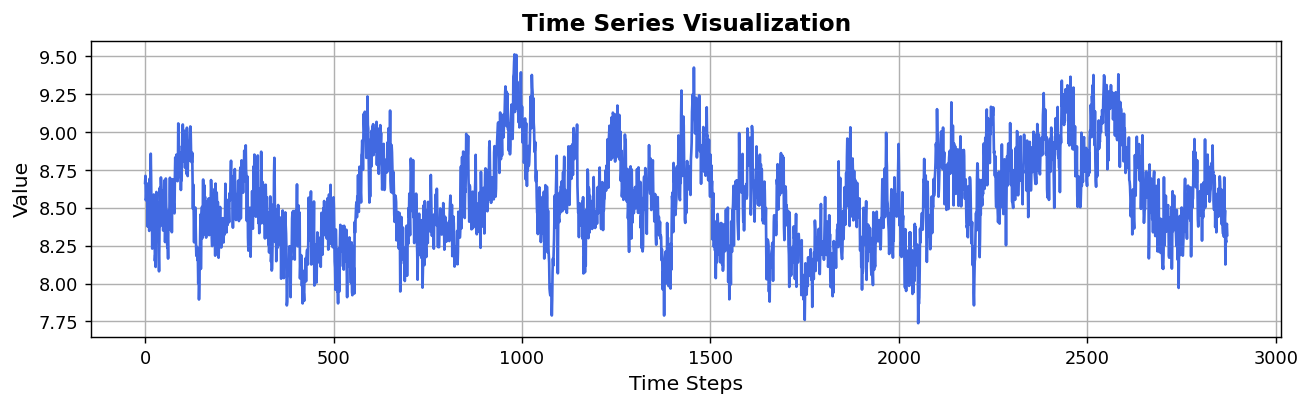

In [5]:
def kalman_filter_innovations(observations, F, G, H, Q, R):
    """Return one-step prediction innovations."""
    n_obs = len(observations)
    p = F.shape[0]
    x = np.zeros(p)
    P = np.eye(p)
    innovations = np.zeros(n_obs)
    H_row = H[0]

    for t in range(n_obs):
        x_pred = F @ x
        P_pred = F @ P @ F.T + Q
        innovation = observations[t] - H_row @ x_pred
        S = H_row @ P_pred @ H_row + R
        K = P_pred @ H_row / S
        x = x_pred + K * innovation
        P = P_pred - np.outer(K, H_row) @ P_pred
        innovations[t] = innovation
    return innovations


def simulate_state_space(white_noise, F, G):
    """Forward-simulate the state equation."""
    p = F.shape[0]
    x = np.zeros(p)
    output = np.zeros(len(white_noise))
    G = G.ravel()
    for t, w in enumerate(white_noise):
        x = F @ x + G * w
        output[t] = x[0]
    return output


innovations = kalman_filter_innovations(normalized_series, F, G, H, Q, R)

rng = np.random.RandomState(7)
white_noise = rng.normal(
    0, scale=np.sqrt(sigma_sq), size=len(time_series) + state_order
)
generated_normalized = simulate_state_space(white_noise, F, G)[state_order:]
generated_series = generated_normalized * std + mean

fig = plot_univariate_time_series(generated_series, dpi=128)

## Step 4: Statistical comparison

We compare the original and generated sequences in the time domain, distribution, autocorrelation, power spectral density, and residual diagnostics.

Text(0.5, 1.01, 'Manual state-space pipeline: original vs generated')

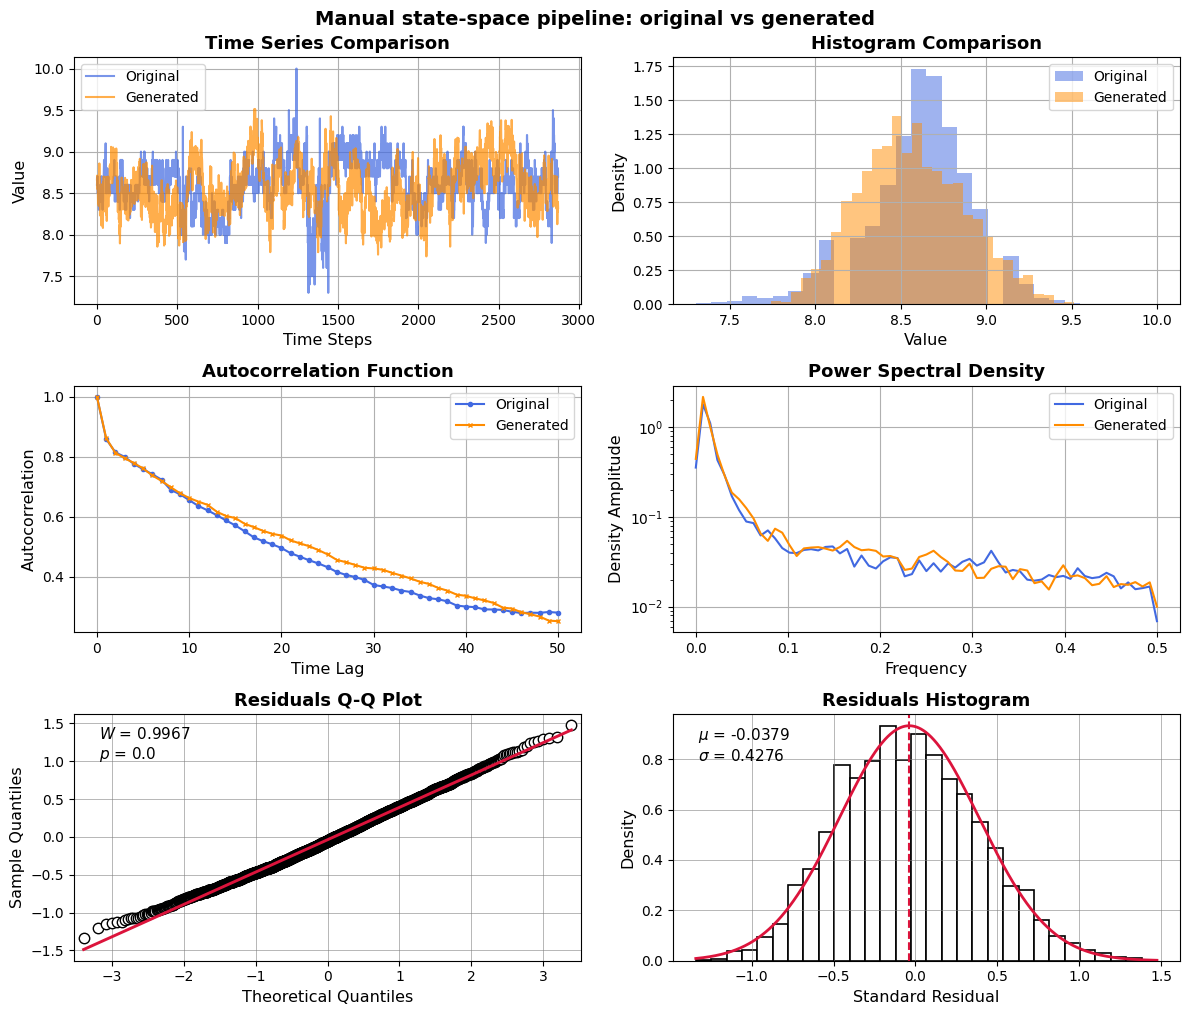

In [6]:
fig = plot_simulator_statistics(
    original_series=time_series,
    generated_series=generated_series,
    residuals=generated_series - time_series,
)
fig.suptitle(
    "Manual state-space pipeline: original vs generated",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

The results above show that the generated sequence captures the second-order statistics of the input data reasonably well. The autocorrelation functions and power spectral densities largely overlap, indicating that the learned state-space model successfully implements a white-noise-to-signal mapping with similar statistical characteristics.

---

## Using `KalmanFilterSimulator` in S2Generator

The entire pipeline above is encapsulated in the `KalmanFilterSimulator` class. Its API is consistent with `WienerFilterSimulator` and `ARIMASimulator`: call `fit` on the input series, then `transform` to generate new samples.

In [7]:
simulator = KalmanFilterSimulator(state_order=8, revin=True, random_state=42)
simulator.fit(time_series)

print("Fit summary")
print(f"  state_order : {simulator.state_order}")
print(f"  sigma_sq    : {simulator.sigma_sq:.6f}")
print(f"  coeffs      : {simulator.coeffs}")

F_fit, G_fit, H_fit, Q_fit, R_fit = simulator.state_space_matrices
print(f"  state dim   : {F_fit.shape[0]}")

Fit summary
  state_order : 8
  sigma_sq    : 0.222695
  coeffs      : [ 1.         -0.50695985 -0.12302034 -0.14677549 -0.04707042 -0.05037847
 -0.03822214 -0.02872338]
  state dim   : 7


Generated batch shape: (5, 2872)


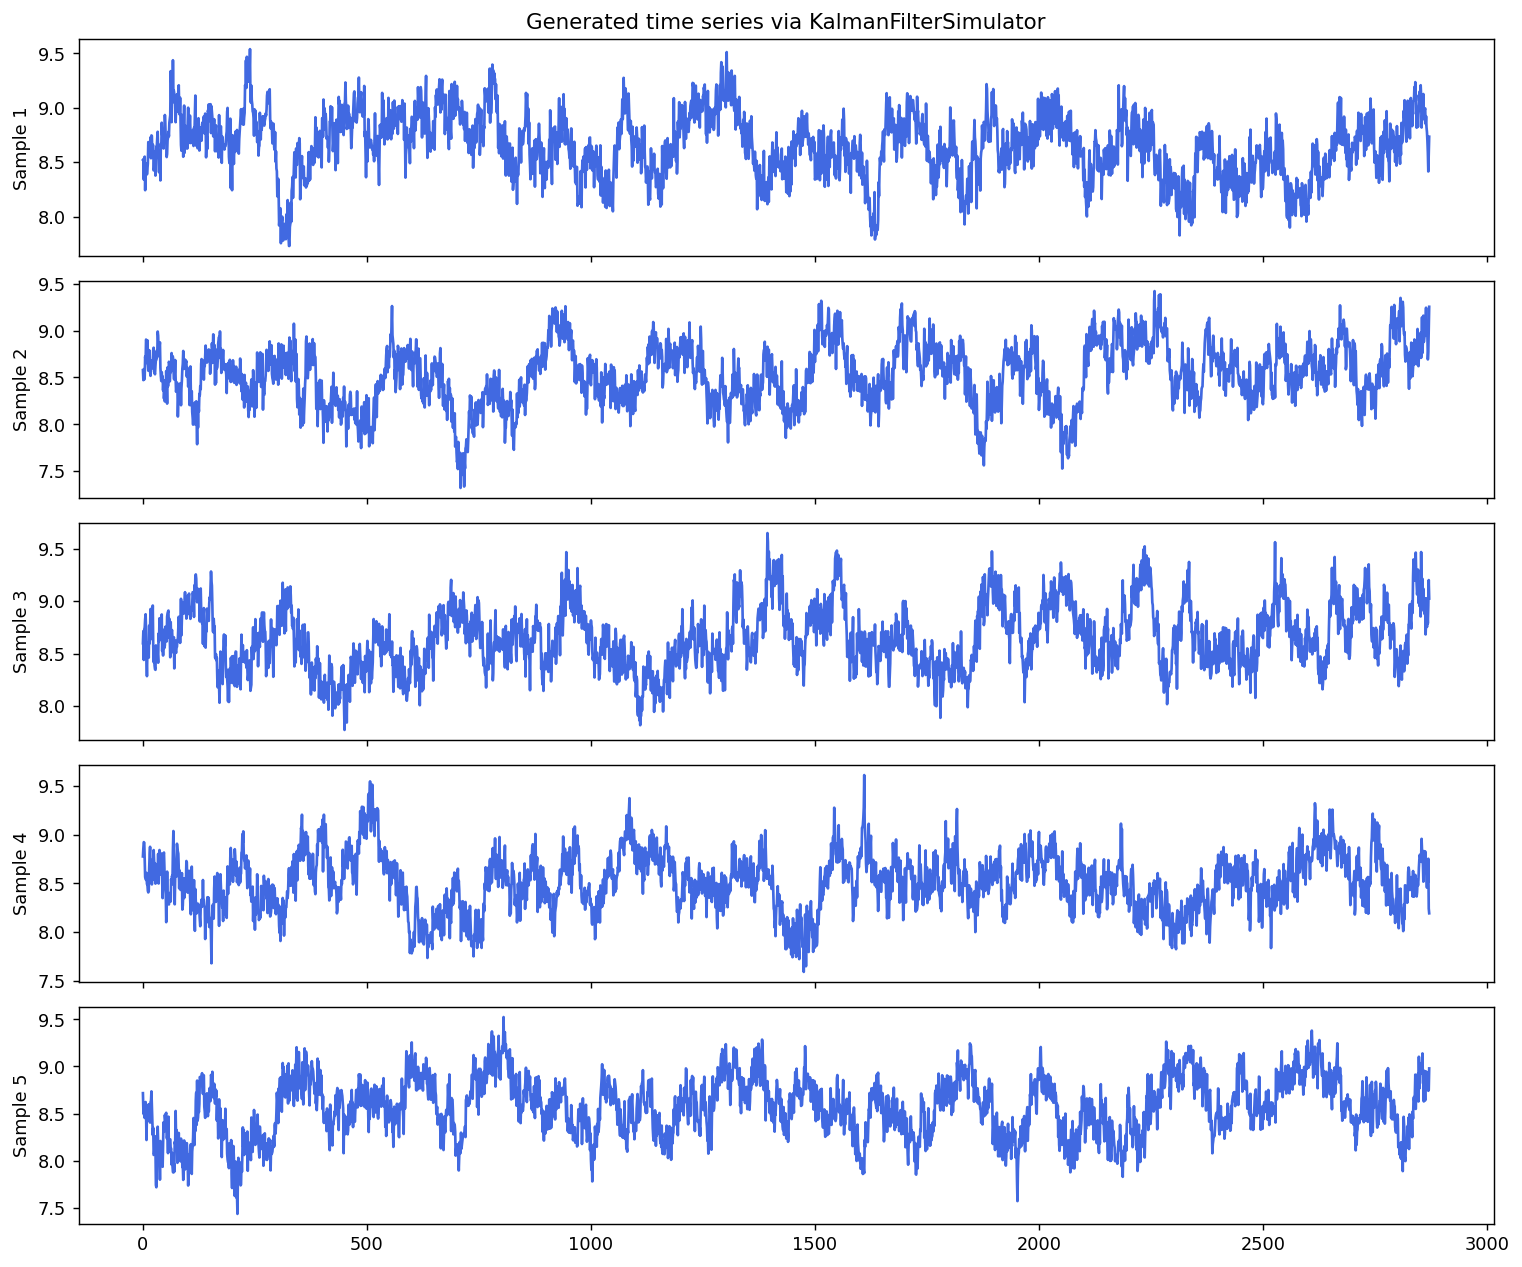

In [8]:
generated_batch = simulator.transform(
    num_samples=5,
    seq_len=len(time_series),
    random_state=128,
)
print("Generated batch shape:", generated_batch.shape)

fig, ax = plt.subplots(5, 1, figsize=(12, 10), sharex=True, dpi=128)
for i, series in enumerate(generated_batch):
    ax[i].plot(series, color="royalblue")
    ax[i].set_ylabel(f"Sample {i + 1}")
ax[0].set_title("Generated time series via KalmanFilterSimulator")
plt.tight_layout()

Text(0.5, 1.01, 'KalmanFilterSimulator: original vs generated')

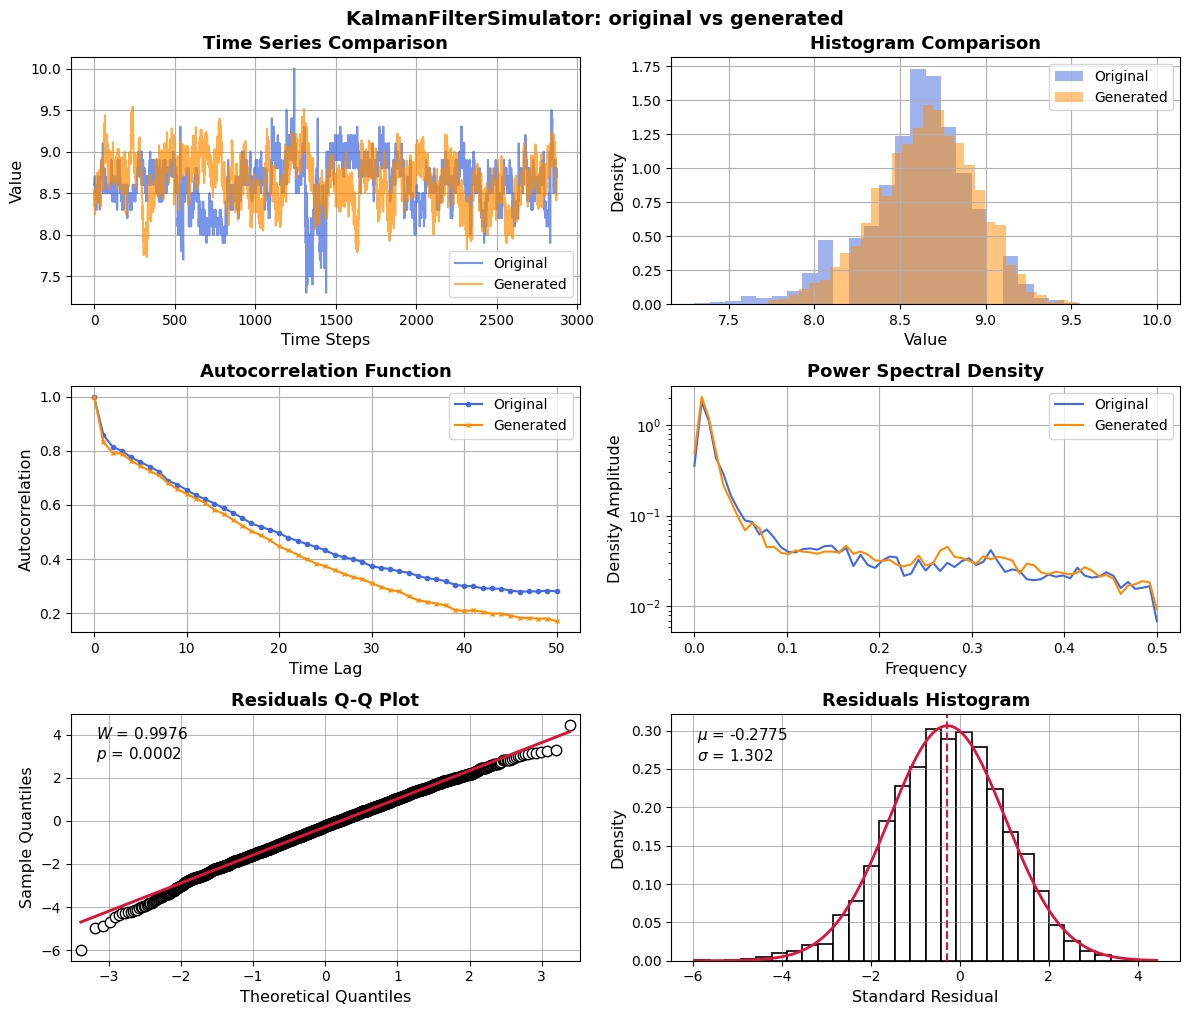

In [9]:
fig = plot_simulator_statistics(
    original_series=time_series,
    generated_series=generated_batch[0],
    residuals=simulator.residuals,
)
fig.suptitle(
    "KalmanFilterSimulator: original vs generated",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

### Supplementary demo: sinusoidal signal

The following cell shows the same workflow on a sinusoidal signal with additive noise, which is a typical non-stationary test case.

Text(0.5, 1.01, 'KalmanFilterSimulator: sine signal test')

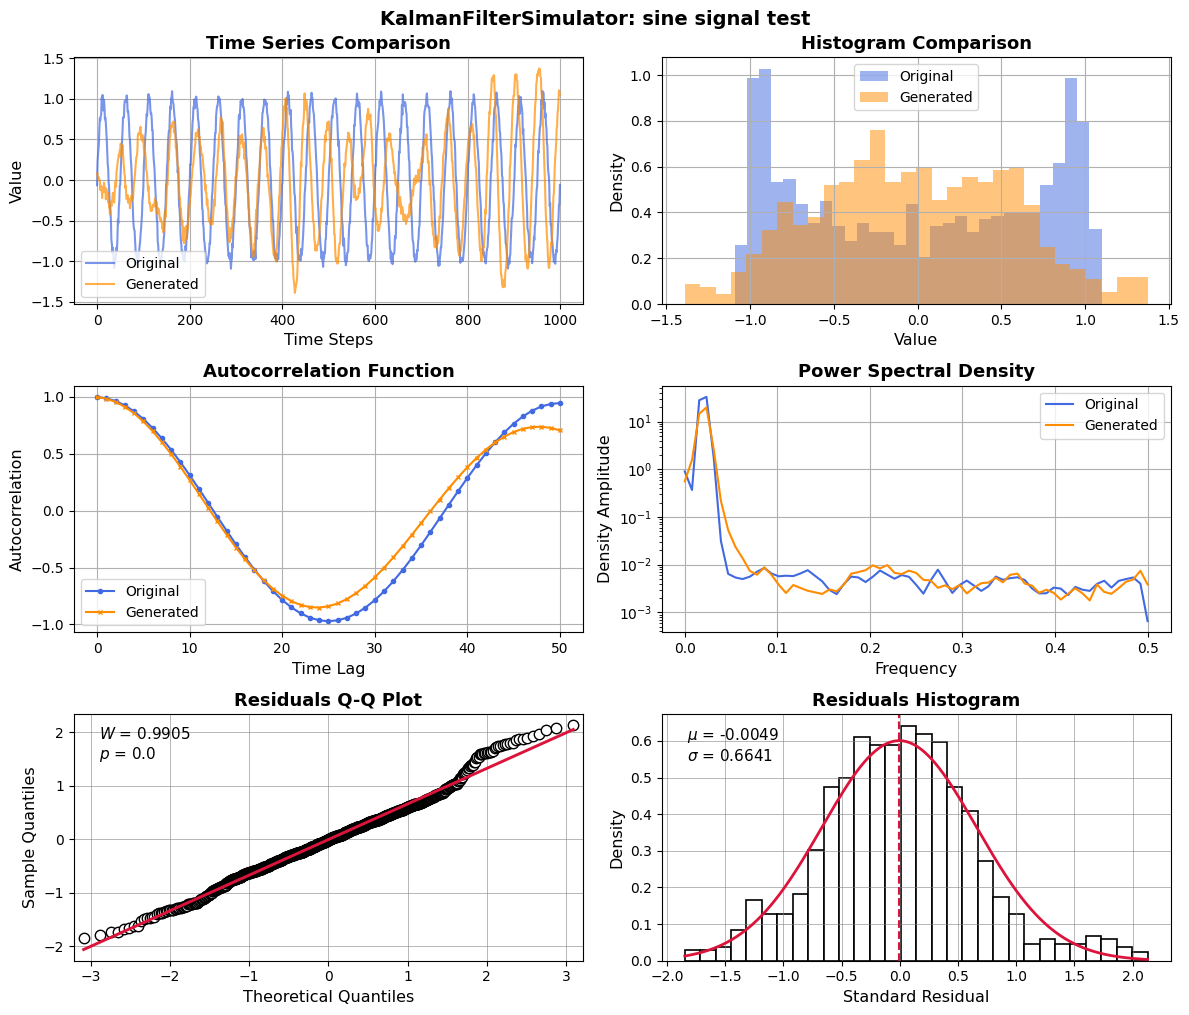

In [10]:
seq_length = 1000
t = np.arange(seq_length)
sine_signal = np.sin(2 * np.pi * t / 50) + 0.05 * np.random.randn(seq_length)

sine_simulator = KalmanFilterSimulator(state_order=8, revin=True, random_state=42)
sine_simulator.fit(sine_signal)
sine_generated = sine_simulator.transform(
    num_samples=1, seq_len=seq_length, random_state=7
)[0]

fig = plot_simulator_statistics(
    original_series=sine_signal,
    generated_series=sine_generated,
    residuals=sine_simulator.residuals,
)
fig.suptitle(
    "KalmanFilterSimulator: sine signal test",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)